In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse

sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=100,
    dpi_save=600,
    facecolor="white",
    frameon=False,
    vector_friendly=True,
)

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")
os.chdir(project_dir)
sys.path.append(str(project_dir))

fig_dir = Path("results/figures/431_lcxyw_exm_mapping")
fig_dir.mkdir(parents=True, exist_ok=True)

table_dir = Path("results/tables/431_lcxyw_exm_mapping")
table_dir.mkdir(parents=True, exist_ok=True)

processed_dir = Path("results/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [2]:
adata_path = processed_dir / "lcxyw_fastmnn_v3.h5ad"
# query_path = processed_dir / "hemo_d1_10_revised_annotation.h5ad"

adata = sc.read_h5ad(adata_path)
# adata_q = sc.read_h5ad(query_path)

adata

AnnData object with n_obs × n_vars = 17431 × 17024
    obs: 'publication', 'matrix_original', 'modality', 'reference_group', 'ref_celltype', 'ref_stage', 'development_day', 'source_label', 'source_stage', 'dataset', 'dataset_stage', 'display_label', 'publication_stage_celltype', 'ref_celltype_merged_v1', 'ref_celltype_merged_v2', 'ref_celltype_merged_v2_id', 'ref_celltype_merged_v3'
    uns: 'matrix_original_colors', 'modality_colors', 'neighbors', 'publication_colors', 'ref_celltype_merged_v2_colors', 'ref_celltype_merged_v3_colors', 'ref_stage_colors', 'reference_group_colors', 'source_label_colors', 'umap'
    obsm: 'X_fastmnn_R', 'X_umap', 'X_umap_fastmnn_R'
    layers: 'counts', 'integration_input', 'log1p_norm'
    obsp: 'connectivities', 'distances'

In [3]:
exm_programmes = {
    "Nasc Mes": [
        "MESP1", "MIXL1", "DLL3", "LHX1", "APLNR", "SP5", "WNT5A"
    ],
    "Trans ExM": [
        "H19", "IGF2", "VIM", "COL3A1", "MDK"
    ],
    "Adv Mes": [
        "CDH11", "MRC2", "COL6A3", "HAND1", "COL4A2",
        "COL6A1", "COL5A2", "SPARC", "LUM", "DCN"
    ],
    "YS Mes": [
        "AQP1", "FRZB", "SLC9A3R1", "POSTN", "APOE",
        "NID2", "PTX3", "NR2F2", "IGFBP3"
    ]
}

In [4]:
gene_presence_records = []

for programme, genes in exm_programmes.items():
    present = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]

    gene_presence_records.append({
        "programme": programme,
        "n_genes": len(genes),
        "n_present": len(present),
        "present_genes": ",".join(present),
        "missing_genes": ",".join(missing),
    })

gene_presence_df = pd.DataFrame(gene_presence_records)
gene_presence_df

,programme,n_genes,n_present,present_genes,missing_genes
0,Nasc Mes,7,7,"MESP1,MIXL1,DLL3,LHX1,APLNR,SP5,WNT5A",
1,Trans ExM,5,3,"VIM,COL3A1,MDK","H19,IGF2"
2,Adv Mes,10,10,"CDH11,MRC2,COL6A3,HAND1,COL4A2,COL6A1,COL5A2,S...",
3,YS Mes,9,9,"AQP1,FRZB,SLC9A3R1,POSTN,APOE,NID2,PTX3,NR2F2,...",


In [5]:
score_cols = []

for programme, genes in exm_programmes.items():
    present = [g for g in genes if g in adata.var_names]
    score_name = f"{programme} score"

    if len(present) >= 2:
        sc.tl.score_genes(
            adata,
            gene_list=present,
            score_name=score_name,
            use_raw=False,
        )
        score_cols.append(score_name)
    else:
        print(f"Skipping {programme}: only {len(present)} genes present")

score_cols

computing score 'Nasc Mes score'
    finished: added
    'Nasc Mes score', score of gene set (adata.obs).
    300 total control genes are used. (0:00:01)
computing score 'Trans ExM score'
    finished: added
    'Trans ExM score', score of gene set (adata.obs).
    100 total control genes are used. (0:00:01)
computing score 'Adv Mes score'
    finished: added
    'Adv Mes score', score of gene set (adata.obs).
    299 total control genes are used. (0:00:01)
computing score 'YS Mes score'
    finished: added
    'YS Mes score', score of gene set (adata.obs).
    400 total control genes are used. (0:00:01)


['Nasc Mes score', 'Trans ExM score', 'Adv Mes score', 'YS Mes score']

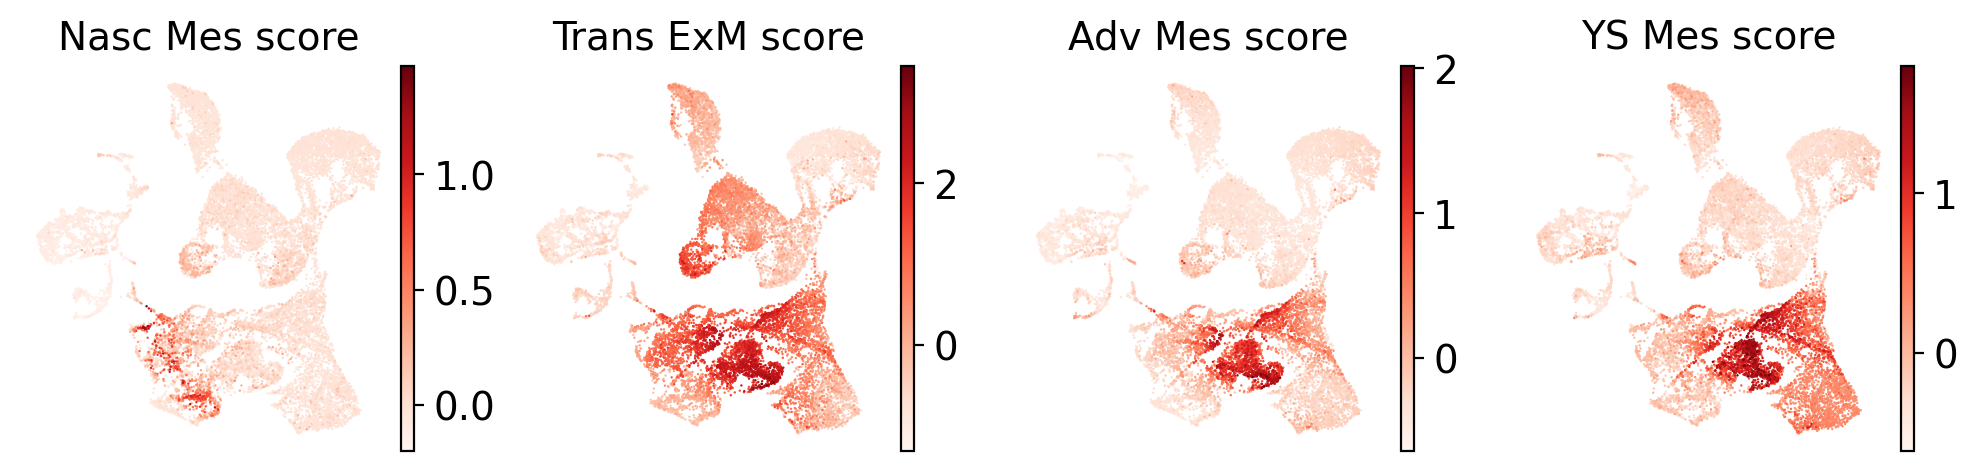

In [8]:
sc.pl.umap(
    adata,
    color=score_cols,
    frameon=False,
    cmap="Reds",
    ncols=4,
    size=3,
    show=False,
)

fig = plt.gcf()
fig.set_size_inches(12, 2.5)

fig.savefig(
    fig_dir / "umap_exm_scores.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [9]:
adata.obs

,publication,matrix_original,modality,reference_group,ref_celltype,ref_stage,development_day,source_label,source_stage,dataset,...,display_label,publication_stage_celltype,ref_celltype_merged_v1,ref_celltype_merged_v2,ref_celltype_merged_v2_id,ref_celltype_merged_v3,Nasc Mes score,Trans ExM score,Adv Mes score,YS Mes score
Yan_SRR491011-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,...,Yan_E6 | TE,Yan et al | E6 | TE,Trophectoderm,Trophectoderm,6,Trophectoderm,-0.087654,-1.012914,-0.534459,-0.438784
Yan_SRR491012-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,...,Yan_E6 | TE,Yan et al | E6 | TE,Trophectoderm,Trophectoderm,6,Trophectoderm,-0.124556,-0.661645,-0.474612,-0.393395
Yan_SRR491013-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,...,Yan_E6 | TE,Yan et al | E6 | TE,Trophectoderm,Trophectoderm,6,Trophectoderm,-0.103757,-0.968347,-0.587811,-0.431736
Yan_SRR491014-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,...,Yan_E6 | TE,Yan et al | E6 | TE,Trophectoderm,Trophectoderm,6,Trophectoderm,-0.129328,-0.646753,-0.502992,-0.395529
Yan_SRR491015-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,...,Yan_E6 | TE,Yan et al | E6 | TE,Trophectoderm,Trophectoderm,6,Trophectoderm,-0.121121,-0.947150,-0.524868,-0.434895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGTGTGAAT_2-wang_ys,Wang et al,wang_ys,sc,yolksac_cs10_11,Ery,CS11,29.0,Wang,Wang_CS11,Wang,...,Wang_CS11 | Ery,Wang et al | CS11 | Ery,Erythroid,Erythroid,1,Erythroid,0.013925,-0.980821,-0.320233,-0.371524
TTTGTCACAGACAAAT_2-wang_ys,Wang et al,wang_ys,sc,yolksac_cs10_11,EC,CS11,29.0,Wang,Wang_CS11,Wang,...,Wang_CS11 | EC,Wang et al | CS11 | EC,Hemogenic Endothelium,Hemato-endothelial,8,Hemato-endothelial,0.058668,1.513073,-0.171684,-0.239202
TTTGTCACATCGGGTC_2-wang_ys,Wang et al,wang_ys,sc,yolksac_cs10_11,MK,CS11,29.0,Wang,Wang_CS11,Wang,...,Wang_CS11 | MK,Wang et al | CS11 | MK,Megakaryocyte,Megakaryocyte,7,Megakaryocyte,-0.041749,-0.522030,-0.405338,-0.386621
TTTGTCACATCGTCGG_2-wang_ys,Wang et al,wang_ys,sc,yolksac_cs10_11,MK,CS11,29.0,Wang,Wang_CS11,Wang,...,Wang_CS11 | MK,Wang et al | CS11 | MK,Megakaryocyte,Megakaryocyte,7,Megakaryocyte,0.075547,-0.548493,-0.432905,-0.353542


In [10]:
group_score_cols = score_cols

source_stage_cellgroup_scores = (
    adata.obs
    .groupby(
        [
            "source_label",
            "ref_stage",
            "development_day",
            "source_stage",
            "ref_celltype_merged_v3",
        ],
        observed=True
    )[group_score_cols]
    .mean()
    .reset_index()
)

source_stage_cellgroup_n = (
    adata.obs
    .groupby(
        [
            "source_label",
            "ref_stage",
            "development_day",
            "source_stage",
            "ref_celltype_merged_v3",
        ],
        observed=True
    )
    .size()
    .reset_index(name="n_cells")
)

source_stage_cellgroup_scores = source_stage_cellgroup_scores.merge(
    source_stage_cellgroup_n,
    on=[
        "source_label",
        "ref_stage",
        "development_day",
        "source_stage",
        "ref_celltype_merged_v3",
    ],
    how="left",
)

source_stage_cellgroup_scores.head()

,source_label,ref_stage,development_day,source_stage,ref_celltype_merged_v3,Nasc Mes score,Trans ExM score,Adv Mes score,YS Mes score,n_cells
0,Cui,CS7,19.0,Cui_CS7,Amnion,0.140823,1.681905,0.507527,0.659014,45
1,Cui,CS7,19.0,Cui_CS7,Connecting Stalk,0.434771,0.877939,0.127763,0.088555,26
2,Cui,CS7,19.0,Cui_CS7,Endoderm,0.334467,0.516497,-0.082769,0.074296,19
3,Cui,CS7,19.0,Cui_CS7,Epiblast/Ectoderm,0.128030,0.084906,-0.322567,-0.066576,64
4,Cui,CS7,19.0,Cui_CS7,Erythroid,-0.020039,0.537073,0.065667,0.453521,22


In [11]:
source_stage_cellgroup_scores.to_csv(
    table_dir / "source_stage_cell_exm_scores.csv",
    index=False,
)

## Stage / endoderm ExM programme heatmaps adapted from notebook 184

In [15]:
# Stage-level ExM programme mapping
# This mirrors the main stage heatmap in 184, adapted to 431 names:
#   scores: "Nasc Mes score", "Trans ExM score", "Adv Mes score", "YS Mes score"
#   stage:  "ref_stage"

stage_score_cols = [
    "Nasc Mes score",
    "Trans ExM score",
    "Adv Mes score",
    "YS Mes score",
]
stage_score_cols = [c for c in stage_score_cols if c in adata.obs.columns]
print(stage_score_cols)

stage_scores = (
    adata.obs
    .groupby("ref_stage", observed=True)[stage_score_cols]
    .mean()
    .reset_index()
)

stage_n = (
    adata.obs
    .groupby("ref_stage", observed=True)
    .size()
    .reset_index(name="n_cells")
)

stage_scores = stage_scores.merge(stage_n, on="ref_stage", how="left")

stage_order = [
    "Zygote",
    "E1", "E2", "E3", "E4", "E5", "E6", "E7", "E8", "E9", "E10", "E12", "E14",
    "CS7", "CS8", "CS9", "CS10", "CS11",
]

stage_scores["ref_stage"] = pd.Categorical(
    stage_scores["ref_stage"].astype(str),
    categories=[s for s in stage_order if s in stage_scores["ref_stage"].astype(str).values],
    ordered=True,
)
stage_scores = stage_scores.sort_values("ref_stage")

stage_scores.to_csv(
    table_dir / "stage_exm_programme_scores.csv",
    index=False,
)

stage_mat = stage_scores.set_index("ref_stage")[stage_score_cols]

# Column-wise z-score, same logic as 184
stage_mat_z = (stage_mat - stage_mat.mean(axis=0)) / stage_mat.std(axis=0)
stage_mat_z = stage_mat_z.replace([np.inf, -np.inf], np.nan).fillna(0)

stage_mat.to_csv(table_dir / "stage_exm_programme_score_raw_matrix.csv")
stage_mat_z.to_csv(table_dir / "stage_exm_programme_score_zscore_matrix.csv")

['Nasc Mes score', 'Trans ExM score', 'Adv Mes score', 'YS Mes score']


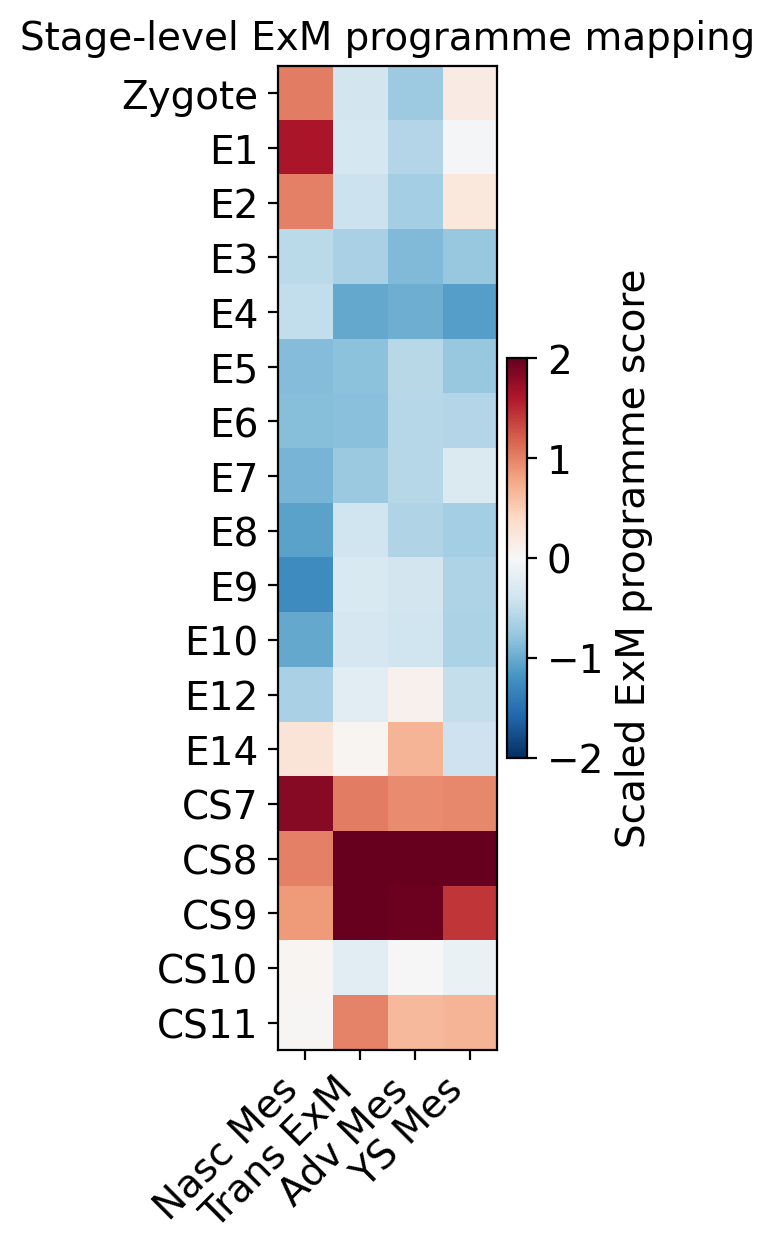

In [37]:
fig, ax = plt.subplots(figsize=(3, 6.5))

im = ax.imshow(
    stage_mat_z.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    interpolation="nearest",
)

ax.grid(False)
ax.minorticks_off()

ax.set_xticks(range(stage_mat_z.shape[1]))
ax.set_xticklabels(
    [x.replace(" score", "") for x in stage_mat_z.columns],
    rotation=45,
    ha="right",
)

ax.set_yticks(range(stage_mat_z.shape[0]))
ax.set_yticklabels(stage_mat_z.index.astype(str))

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.08,   # colorbar 宽度，越大越粗
    pad=0.04,
    shrink=0.42,     # colorbar 高度，越小越短
)
cbar.set_label("Scaled ExM programme score")
cbar.ax.grid(False)

ax.set_title("Stage-level ExM programme mapping")
plt.tight_layout()

fig.savefig(
    fig_dir / "stage_exm_programme_score_heatmap.pdf",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

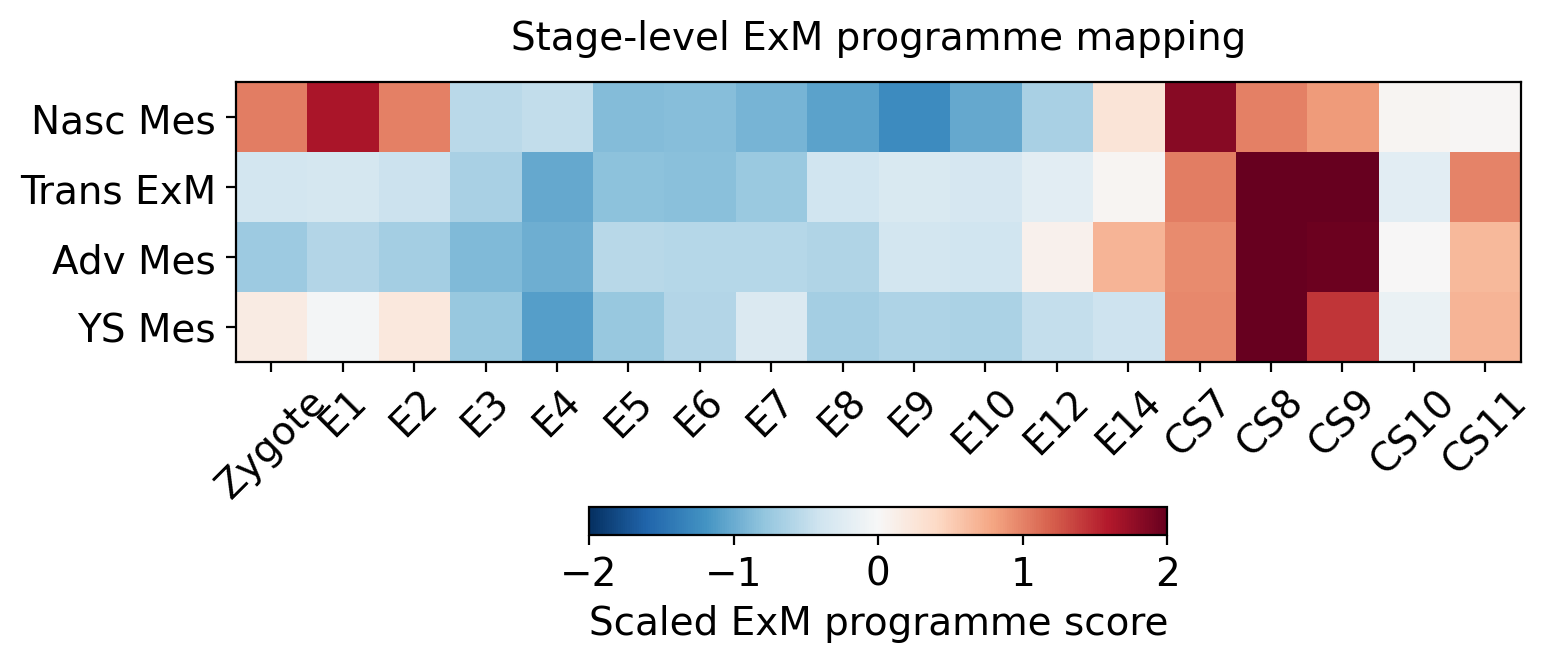

In [36]:
fig, ax = plt.subplots(figsize=(8, 3.5))

im = ax.imshow(
    stage_mat_z.T.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    interpolation="nearest",
)

ax.grid(False)
ax.minorticks_off()

# x-axis: stages
ax.set_xticks(range(stage_mat_z.shape[0]))
ax.set_xticklabels(
    stage_mat_z.index.astype(str),
    rotation=45,
    ha="center",
    va="top",
)

# y-axis: ExM programmes
ax.set_yticks(range(stage_mat_z.shape[1]))
ax.set_yticklabels(
    [x.replace(" score", "") for x in stage_mat_z.columns]
)

ax.set_title("Stage-level ExM programme mapping", pad=12)

# horizontal colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    fraction=0.12,
    pad=0.3,
    shrink=0.45,
)
cbar.set_label("Scaled ExM programme score")
cbar.ax.grid(False)

plt.tight_layout()

fig.savefig(
    fig_dir / "stage_exm_programme_score_heatmap_horizontal.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [40]:
for x in sorted(adata.obs["ref_celltype_merged_v3"].astype(str).unique()):
    print(x)

Advanced Mesoderm
Allantois
Ambiguous
Amnion
Blood Progenitors
Connecting Stalk
Definitive Endoderm
Early Hypoblast
Endoderm
Epiblast
Epiblast/Ectoderm
Erythroid
ExE Mesoderm
Gut Endoderm
Hemato-endothelial
Late Hypoblast
Megakaryocyte
Mesoderm
Mixed Mesoderm
Myeloid
Neural
Neuromesodermal Progenitor
Preimplantation
Primitive Streak
Primordial Germ Cells
Surface Ectoderm
Trophectoderm
Trophoblast
Unknown
Visceral Endoderm
YS Endoderm
YS Mesoderm


In [41]:
endo_score_cols = [
    "Nasc Mes score",
    "Trans ExM score",
    "Adv Mes score",
    "YS Mes score",
]
endo_score_cols = [c for c in endo_score_cols if c in adata.obs.columns]
print(endo_score_cols)

celltype_key = "ref_celltype_merged_v3"

endoderm_related_celltypes = [
    "Early Hypoblast",
    "Late Hypoblast",
    "Endoderm",
    "Definitive Endoderm",
    "Gut Endoderm",
    "Visceral Endoderm",
    "YS Endoderm",
]

endoderm_related_celltypes = [
    x for x in endoderm_related_celltypes
    if x in adata.obs[celltype_key].astype(str).unique()
]

print(endoderm_related_celltypes)

endo_obs = adata.obs.loc[
    adata.obs[celltype_key].astype(str).isin(endoderm_related_celltypes)
].copy()

group_keys = ["ref_stage", celltype_key]
if "development_day" in endo_obs.columns:
    group_keys = ["ref_stage", "development_day", celltype_key]

endo_pop_stage_scores = (
    endo_obs
    .groupby(group_keys, observed=True)[endo_score_cols]
    .mean()
    .reset_index()
)

endo_pop_stage_n = (
    endo_obs
    .groupby(group_keys, observed=True)
    .size()
    .reset_index(name="n_cells")
)

endo_pop_stage_scores = endo_pop_stage_scores.merge(
    endo_pop_stage_n,
    on=group_keys,
    how="left",
)

stage_order = [
    "Zygote",
    "E1", "E2", "E3", "E4", "E5", "E6", "E7", "E8", "E9", "E10", "E12", "E14",
    "CS7", "CS8", "CS9", "CS10", "CS11",
]

endo_pop_stage_scores["ref_stage"] = pd.Categorical(
    endo_pop_stage_scores["ref_stage"].astype(str),
    categories=[
        s for s in stage_order
        if s in endo_pop_stage_scores["ref_stage"].astype(str).values
    ],
    ordered=True,
)

endo_pop_stage_scores[celltype_key] = pd.Categorical(
    endo_pop_stage_scores[celltype_key].astype(str),
    categories=[
        x for x in endoderm_related_celltypes
        if x in endo_pop_stage_scores[celltype_key].astype(str).values
    ],
    ordered=True,
)

endo_pop_stage_scores = endo_pop_stage_scores.sort_values(
    ["ref_stage", celltype_key]
)

endo_pop_stage_scores["label"] = (
    endo_pop_stage_scores["ref_stage"].astype(str)
    + " | "
    + endo_pop_stage_scores[celltype_key].astype(str)
)

endo_pop_stage_scores.to_csv(
    table_dir / "focused_endoderm_population_stage_exm_scores.csv",
    index=False,
)

endo_mat = endo_pop_stage_scores.set_index("label")[endo_score_cols]
endo_mat = endo_mat[~endo_mat.index.duplicated(keep="first")]

endo_mat_z = (endo_mat - endo_mat.mean(axis=0)) / endo_mat.std(axis=0)
endo_mat_z = endo_mat_z.replace([np.inf, -np.inf], np.nan).fillna(0)

endo_mat.to_csv(
    table_dir / "focused_endoderm_population_stage_exm_score_raw_matrix.csv"
)
endo_mat_z.to_csv(
    table_dir / "focused_endoderm_population_stage_exm_score_zscore_matrix.csv"
)

['Nasc Mes score', 'Trans ExM score', 'Adv Mes score', 'YS Mes score']
['Early Hypoblast', 'Late Hypoblast', 'Endoderm', 'Definitive Endoderm', 'Gut Endoderm', 'Visceral Endoderm', 'YS Endoderm']


/tmp/ipykernel_3904972/1399150747.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


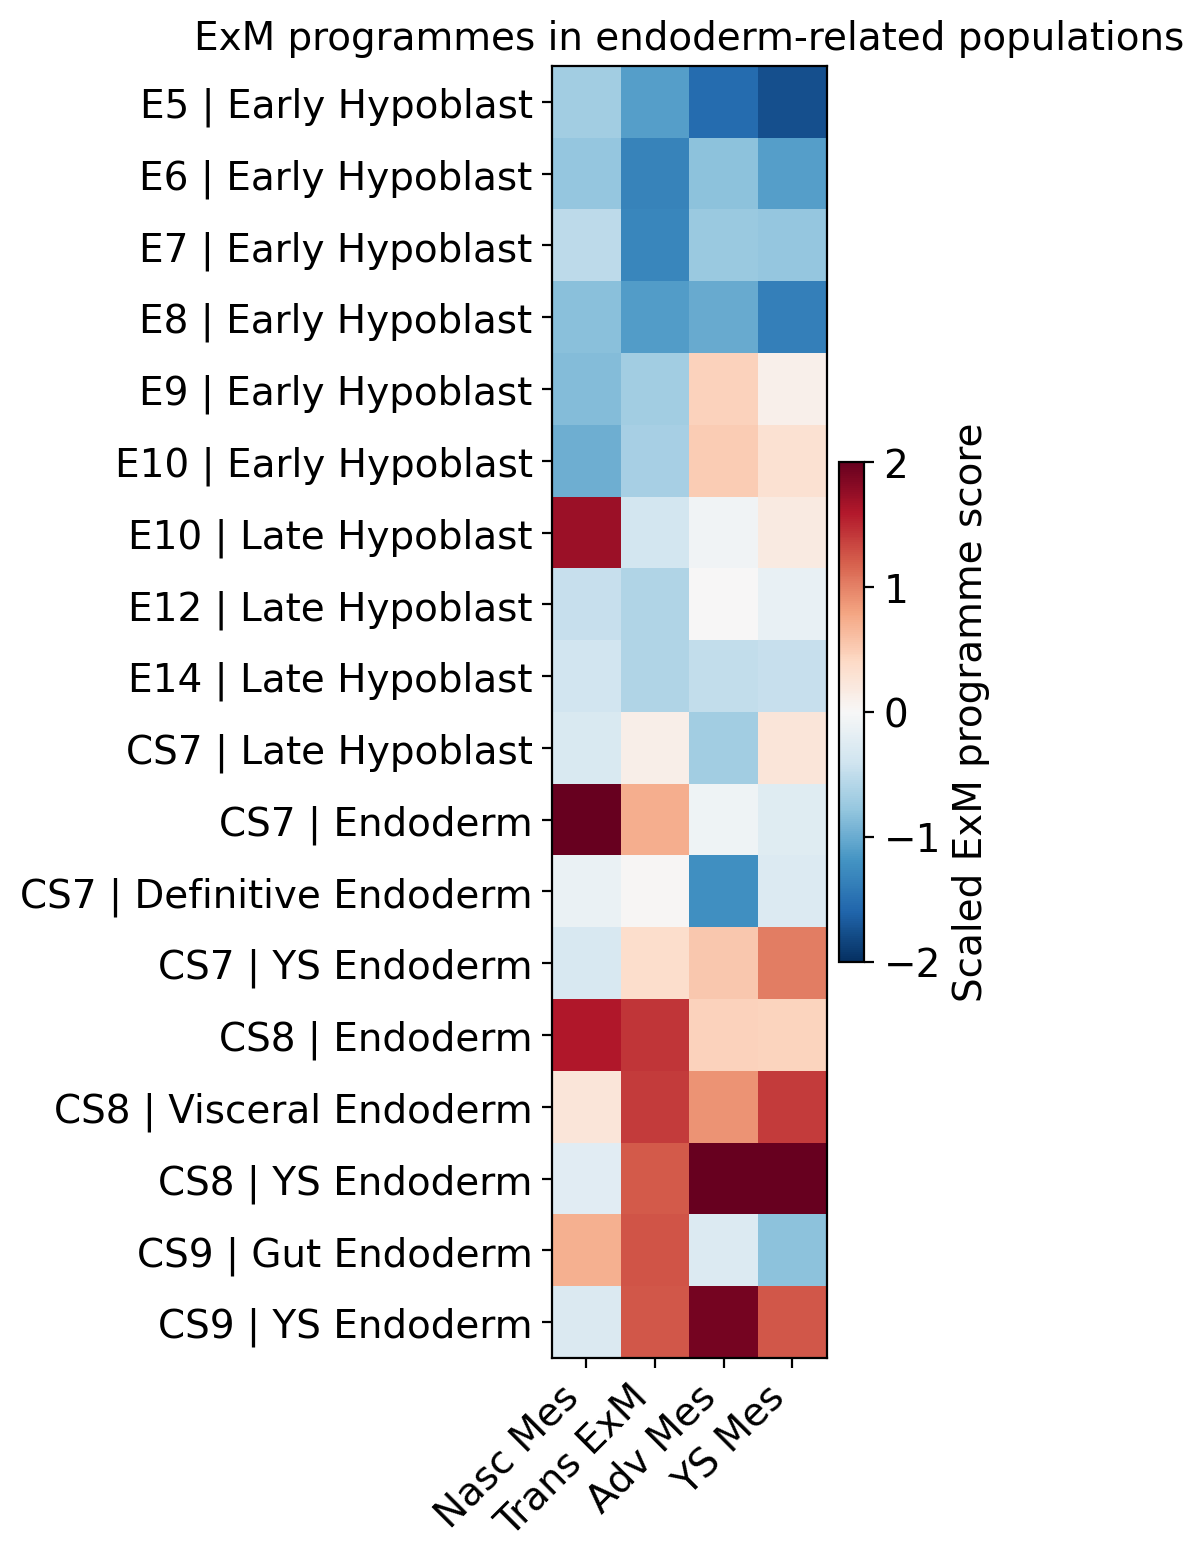

In [52]:
fig, ax = plt.subplots(figsize=(2, 8.5))

im = ax.imshow(
    endo_mat_z.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    interpolation="nearest",
)

ax.grid(False)
ax.minorticks_off()

ax.set_xticks(range(endo_mat_z.shape[1]))
ax.set_xticklabels(
    [x.replace(" score", "") for x in endo_mat_z.columns],
    rotation=45,
    ha="right",
)

ax.set_yticks(range(endo_mat_z.shape[0]))
ax.set_yticklabels(endo_mat_z.index)

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.08,   # colorbar 宽度，越大越粗
    pad=0.04,
    shrink=0.42,     # colorbar 高度，越小越短
)
cbar.set_label("Scaled ExM programme score")
cbar.ax.grid(False)

ax.set_title("ExM programmes in endoderm-related populations")
plt.tight_layout()

fig.savefig(
    fig_dir / "main_endoderm_population_stage_exm_only_heatmap.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

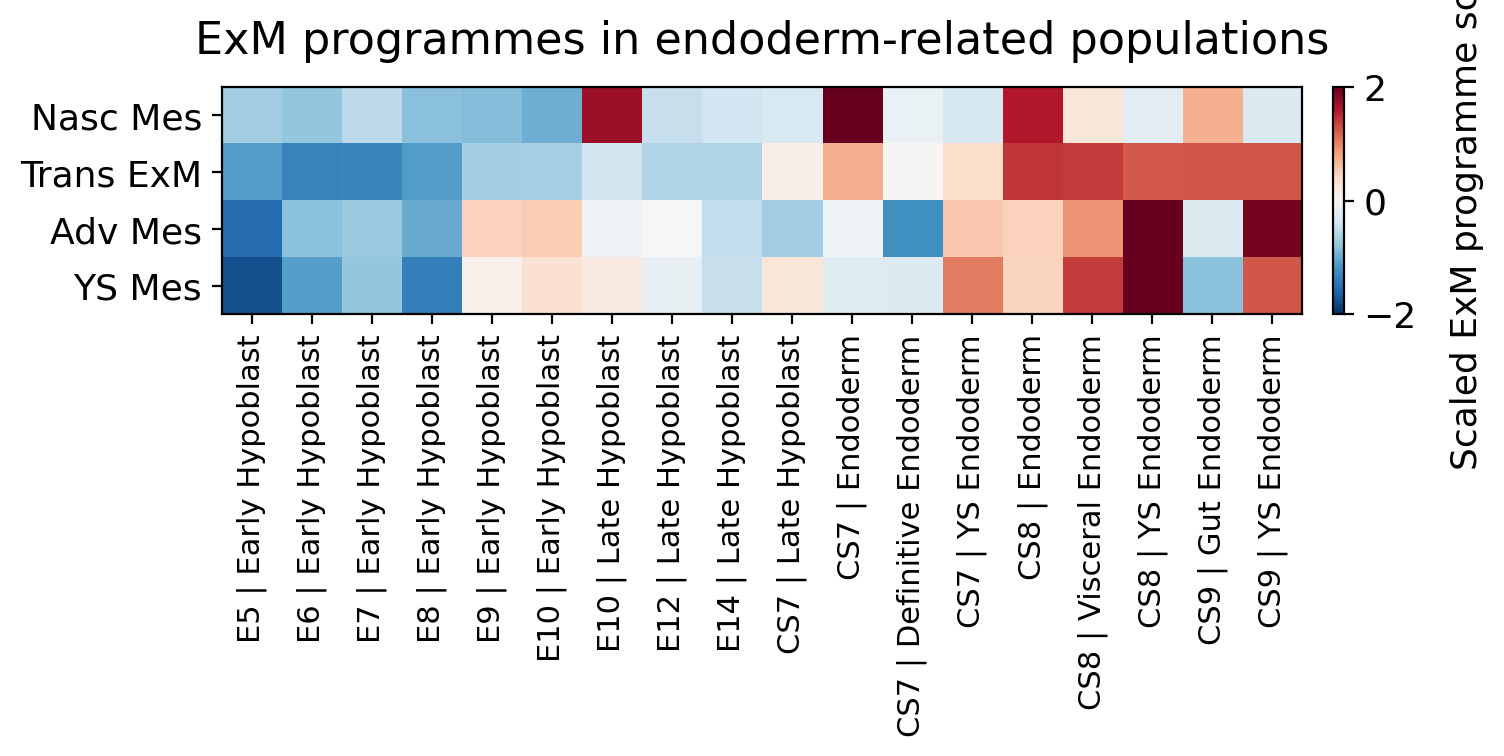

In [72]:
# Horizontal version

endo_mat_z_T = endo_mat_z.T

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(
    endo_mat_z_T.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    interpolation="nearest",
)

ax.grid(False)
ax.minorticks_off()

ax.set_xticks(range(endo_mat_z_T.shape[1]))
ax.set_xticklabels(
    endo_mat_z_T.columns,
    rotation=90,
    ha="center",
    va="top",
    fontsize=11,
)

ax.set_yticks(range(endo_mat_z_T.shape[0]))
ax.set_yticklabels(
    [x.replace(" score", "") for x in endo_mat_z_T.index],
    fontsize=13,
)

ax.set_title(
    "ExM programmes in endoderm-related populations",
    pad=12,
    fontsize=16,
)

# vertical colorbar on the right
cbar = plt.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.08,   # 比之前粗一点
    pad=0.025,
    shrink=1.0,      # 比之前长一点
)

cbar.set_label(
    "Scaled ExM programme score",
    fontsize=13,
    labelpad=12,
)
cbar.ax.tick_params(labelsize=13)
cbar.ax.grid(False)

plt.tight_layout()

fig.savefig(
    fig_dir / "main_endoderm_population_stage_exm_only_heatmap_horizontal.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()